# Proyek Akhir: Menyelesaikan Permasalahan Institusi Pendidikan

- Nama: Arisyi Said Tanjung
- Email: arisyisaid14@gmail.com
- Id Dicoding:arisyisaid

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, roc_curve, auc, make_scorer, recall_score, precision_score, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

os.makedirs('model', exist_ok=True)

In [2]:
#set styles
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

### Menyiapkan data yang akan digunakan

In [3]:
df = pd.read_csv("/content/data.csv", sep=";")
print('data.csv shape: ', df.shape)

df.head()

data.csv shape:  (4424, 37)


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

In [5]:
df.describe()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [6]:
df.isnull().sum()

,0
Marital_status,0
Application_mode,0
Application_order,0
Course,0
Daytime_evening_attendance,0
Previous_qualification,0
Previous_qualification_grade,0
Nacionality,0
Mothers_qualification,0
Fathers_qualification,0


In [7]:
duplicate_rows = df[df.duplicated()]
print(f"Duplicate rows found: {duplicate_rows.shape[0]}")

Duplicate rows found: 0


In [8]:
#Check Target variable
print(df['Status'].value_counts())
print(f"\n")
print(df['Status'].value_counts(normalize=True)*100)

Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


Status
Graduate    49.932188
Dropout     32.120253
Enrolled    17.947559
Name: proportion, dtype: float64


## Data Preparation / Preprocessing

### Separate Data Model (graduate & dropout) dari Data Enrolled

In [9]:
#pisahkan enrolled student untuk dijadikan model
df_enrolled = df[df['Status'] == 'Enrolled'].copy()

#Check Target variable
print(df_enrolled['Status'].value_counts())
print(f"\n")
print(df_enrolled['Status'].value_counts(normalize=True)*100)

Status
Enrolled    794
Name: count, dtype: int64


Status
Enrolled    100.0
Name: proportion, dtype: float64


In [10]:
#define Model training (only dropout and graduate)
df_model = df[df['Status'].isin(['Dropout', 'Graduate'])].copy()

In [11]:
#Check Dataset
print(f"Base dataset: {df.shape[0]} rows")
print(f"Enrolled (excluded): {df_enrolled.shape[0]} rows")
print(f"Model dataset (Dropout+Graduate): {df_model.shape[0]} rows")



Base dataset: 4424 rows
Enrolled (excluded): 794 rows
Model dataset (Dropout+Graduate): 3630 rows


In [12]:
#Check Target variable
print(df_model['Status'].value_counts())
print(f"\n")
print(df_model['Status'].value_counts(normalize=True)*100)

Status
Graduate    2209
Dropout     1421
Name: count, dtype: int64


Status
Graduate    60.853994
Dropout     39.146006
Name: proportion, dtype: float64


### Label Encoding

In [13]:
#Encode Target
le = LabelEncoder()
df_model['Status_encoded'] = le.fit_transform(df_model['Status'])
print("Encode Mapping:" , dict(zip(le.classes_, le.transform(le.classes_))))

Encode Mapping: {'Dropout': np.int64(0), 'Graduate': np.int64(1)}


### Exploratory Data Analysis

#### Setup EDA

In [14]:
#separate features and target
X = df_model.drop(columns=['Status', 'Status_encoded'])
y = df_model['Status_encoded']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print("\nTarget distribution in modeling set:")
print(y.value_counts(normalize=True) * 100)

#1=graduate, #0=Dropout


Features shape: (3630, 36)
Target shape: (3630,)

Target distribution in modeling set:
Status_encoded
1    60.853994
0    39.146006
Name: proportion, dtype: float64


In [15]:
#Pilih Numeric Featuers
numeric_cols = X.select_dtypes(include=[np.number]).columns
categorical_cols = X.select_dtypes(include=['object']).columns

#### Univariate Analysis

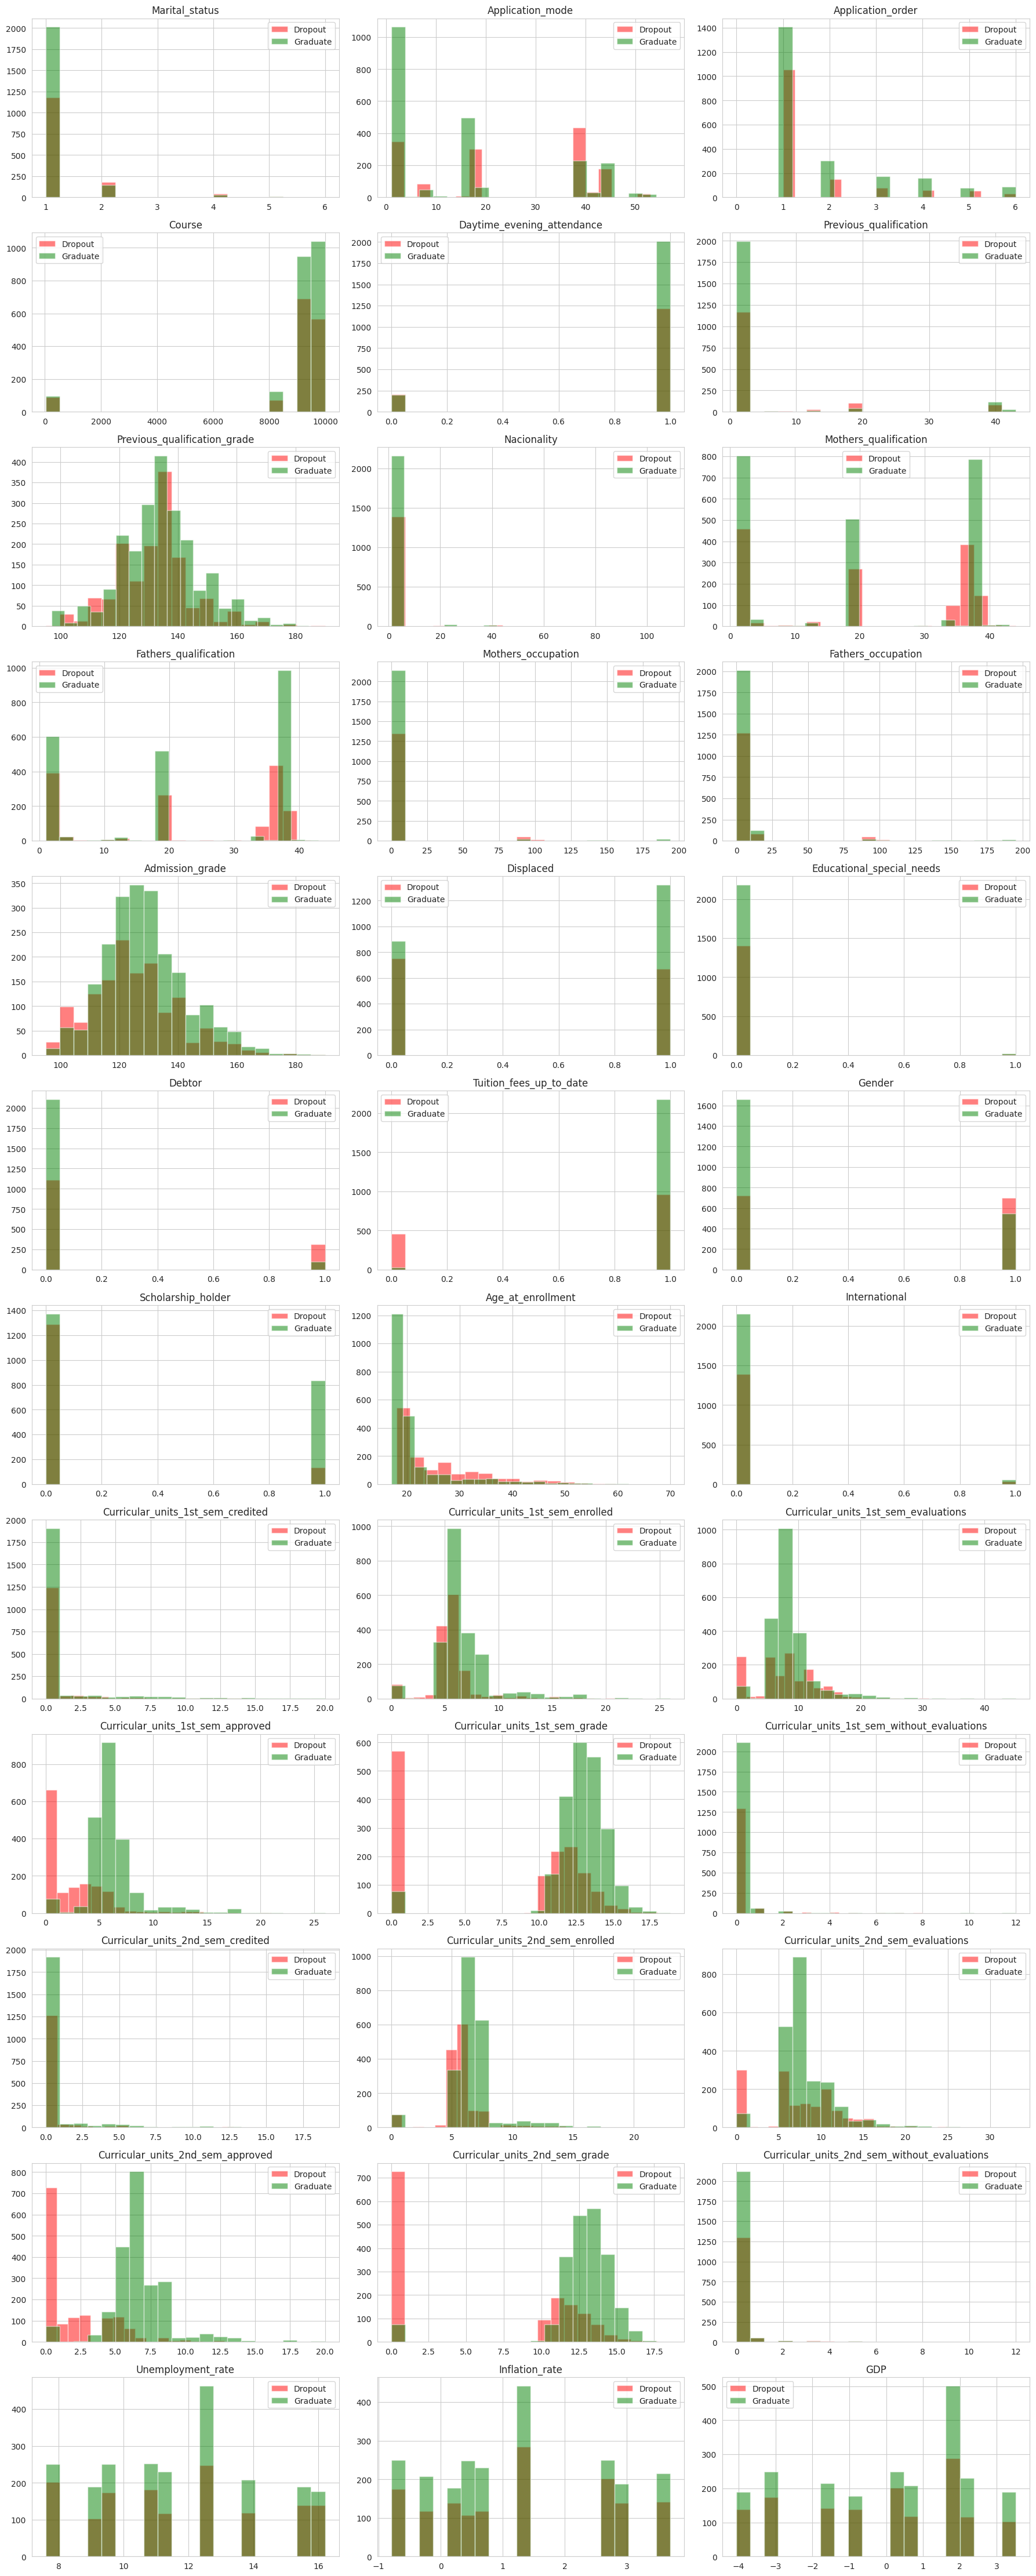

In [16]:
#histogram numeric
fig, axes = plt.subplots(nrows=len(numeric_cols)//3 + 1, ncols=3, figsize=(18, 4*len(numeric_cols)//3))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    ax = axes[i]
    # Histogram for Dropout and Graduate separately
    for status, color in zip([0,1], ['red', 'green']):
        data = X[y == status][col]
        ax.hist(data, alpha=0.5, bins=20, label=f'{"Dropout" if status==0 else "Graduate"}', color=color)
    ax.set_title(col)
    ax.legend()
for i in range(len(numeric_cols), len(axes)):
    axes[i].set_visible(False)
plt.tight_layout()
plt.show()


In [17]:
print(y.value_counts())

Status_encoded
1    2209
0    1421
Name: count, dtype: int64


#### Correlation Analysis

In [18]:
#Top 10 Corr
correlations = X.corrwith(y).abs().sort_values(ascending=False)
print("Top 10 features correlated with student status (absolute):")
print(correlations.head(15))

Top 10 features correlated with student status (absolute):
Curricular_units_2nd_sem_approved       0.653995
Curricular_units_2nd_sem_grade          0.605350
Curricular_units_1st_sem_approved       0.554881
Curricular_units_1st_sem_grade          0.519927
Tuition_fees_up_to_date                 0.442138
Scholarship_holder                      0.313018
Age_at_enrollment                       0.267229
Debtor                                  0.267207
Gender                                  0.251955
Application_mode                        0.244507
Curricular_units_2nd_sem_enrolled       0.182897
Curricular_units_1st_sem_enrolled       0.161074
Admission_grade                         0.128058
Displaced                               0.126113
Curricular_units_2nd_sem_evaluations    0.119239
dtype: float64


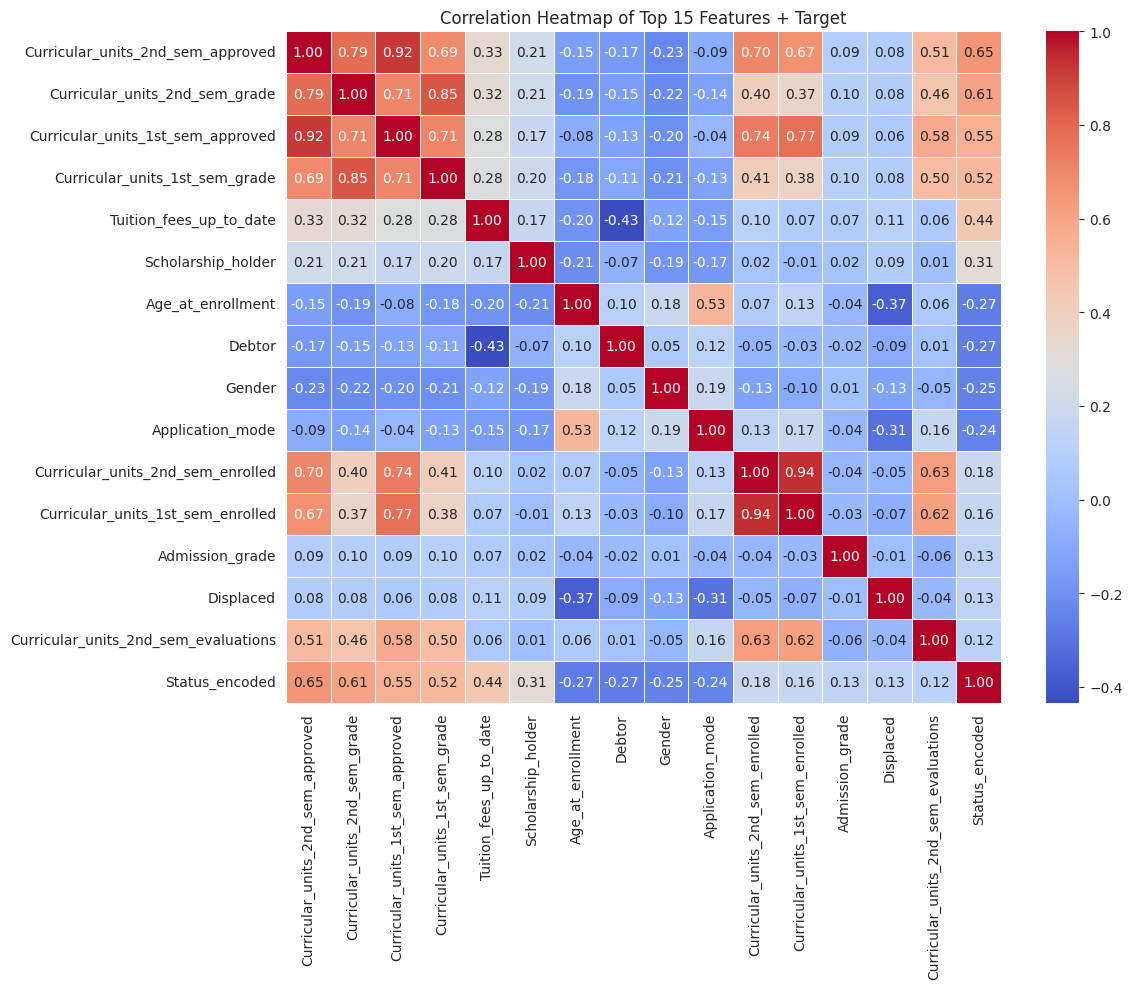

In [19]:
#heatmap corr top 15
top_features = correlations.head(15).index.tolist()
top_features.append('Status_encoded')
plt.figure(figsize=(12, 10))
sns.heatmap(df_model[top_features].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Top 15 Features + Target')
plt.tight_layout()
plt.show()

#### Features Engineering

In [20]:
df_model_eng = df_model.copy()
print(f"shape: ", df_model_eng.shape)

shape:  (3630, 38)


In [21]:
# Small epsilon to avoid division by zero
eps = 1e-6

# 1st semester approval rate
df_model_eng['approval_rate_1st'] = df_model_eng['Curricular_units_1st_sem_approved'] / (df_model_eng['Curricular_units_1st_sem_enrolled'] + eps)
df_model_eng['failure_rate_1st'] = (df_model_eng['Curricular_units_1st_sem_enrolled'] - df_model_eng['Curricular_units_1st_sem_approved']) / (df_model_eng['Curricular_units_1st_sem_enrolled'] + eps)

# 2nd semester approval rate
df_model_eng['approval_rate_2nd'] = df_model_eng['Curricular_units_2nd_sem_approved'] / (df_model_eng['Curricular_units_2nd_sem_enrolled'] + eps)
df_model_eng['failure_rate_2nd'] = (df_model_eng['Curricular_units_2nd_sem_enrolled'] - df_model_eng['Curricular_units_2nd_sem_approved']) / (df_model_eng['Curricular_units_2nd_sem_enrolled'] + eps)

# Average grade across both semesters
df_model_eng['grade_avg'] = (df_model_eng['Curricular_units_1st_sem_grade'] + df_model_eng['Curricular_units_2nd_sem_grade']) / 2

print("New features created:")
print(['approval_rate_1st', 'failure_rate_1st', 'approval_rate_2nd', 'failure_rate_2nd', 'grade_avg'])

New features created:
['approval_rate_1st', 'failure_rate_1st', 'approval_rate_2nd', 'failure_rate_2nd', 'grade_avg']


In [22]:
#Col to drop
cols_to_drop = [
    'Curricular_units_1st_sem_enrolled',
    'Curricular_units_1st_sem_approved',
    'Curricular_units_2nd_sem_enrolled',
    'Curricular_units_2nd_sem_approved',
    'Curricular_units_1st_sem_grade',
    'Curricular_units_2nd_sem_grade'
]

# Drop only if they exist
for col in cols_to_drop:
    if col in df_model_eng.columns:
        df_model_eng.drop(columns=[col], inplace=True)

print("Columns dropped:", cols_to_drop)
print("New shape:", df_model_eng.shape)

Columns dropped: ['Curricular_units_1st_sem_enrolled', 'Curricular_units_1st_sem_approved', 'Curricular_units_2nd_sem_enrolled', 'Curricular_units_2nd_sem_approved', 'Curricular_units_1st_sem_grade', 'Curricular_units_2nd_sem_grade']
New shape: (3630, 37)


In [23]:
#check missing value
print("Missing values after feature engineering:")
print(df_model_eng.isnull().sum().sum())

Missing values after feature engineering:
0


In [24]:
#save engineered model dataset
df_model_eng.to_csv('data_engineered.csv', index=False)
print("Engineered dataset saved as 'data_engineered.csv'")

Engineered dataset saved as 'data_engineered.csv'


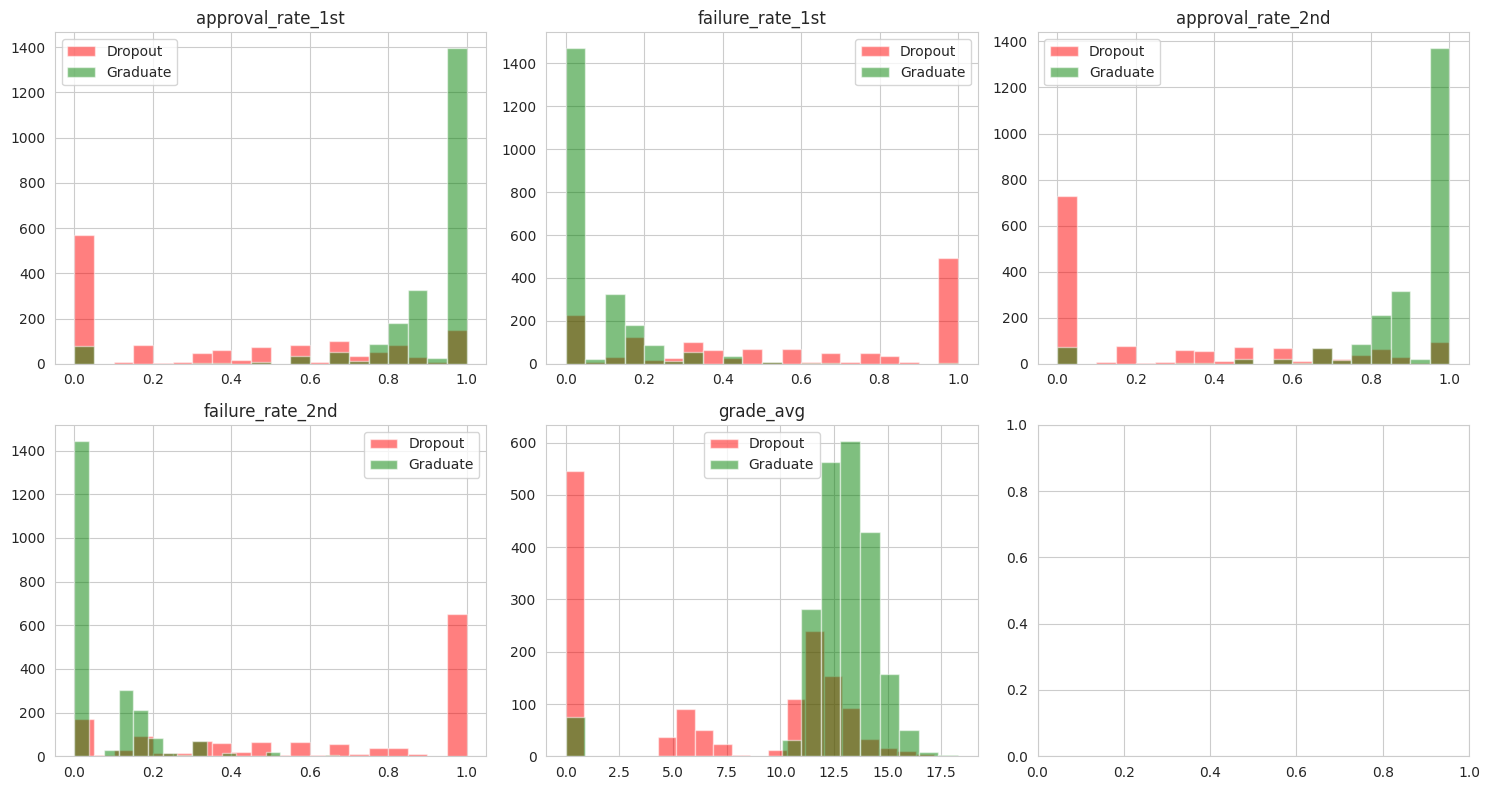

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
new_features = ['approval_rate_1st', 'failure_rate_1st', 'approval_rate_2nd', 'failure_rate_2nd', 'grade_avg']
for i, col in enumerate(new_features):
    row = i // 3
    col_idx = i % 3
    ax = axes[row, col_idx]
    for status, color in zip([0,1], ['red', 'green']):
        data = df_model_eng[df_model_eng['Status_encoded'] == status][col]
        ax.hist(data, alpha=0.5, bins=20, label=f'{"Dropout" if status==0 else "Graduate"}', color=color)
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

## Modeling

In [26]:
#check df yang akan digunakan
print("Engineered dataset shape:", df_model_eng.shape)

#Check Target
print("Target distribution:\n", df_model_eng['Status_encoded'].value_counts())

Engineered dataset shape: (3630, 37)
Target distribution:
 Status_encoded
1    2209
0    1421
Name: count, dtype: int64


In [27]:
#Split Data
X = df_model_eng.drop(columns=['Status', 'Status_encoded'])
y = df_model_eng['Status_encoded']

#### Split Train-Test Data

In [28]:
#Split train and test 80:20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")
print("Train class distribution:\n", y_train.value_counts(normalize=True))


Train size: 2904, Test size: 726
Train class distribution:
 Status_encoded
1    0.608471
0    0.391529
Name: proportion, dtype: float64


In [29]:
#Winsorization

#define
numeric_cols = X.select_dtypes(include=[np.number]).columns

# Compute bounds from training data
bounds = {}
for col in numeric_cols:
    lower = X_train[col].quantile(0.01)
    upper = X_train[col].quantile(0.99)
    bounds[col] = (lower, upper)

# Apply capping to train and test
def cap_data(df, bounds):
    df = df.copy()
    for col, (low, high) in bounds.items():
        if col in df.columns:
            df[col] = df[col].clip(low, high)
    return df

X_train_capped = cap_data(X_train, bounds)
X_test_capped = cap_data(X_test, bounds)

print("Winsorization applied to numeric columns using training-set bounds.")


Winsorization applied to numeric columns using training-set bounds.


#### Handle Imbalance dengan SMOTe

In [30]:
#apply smote ke data training

smote = SMOTE(random_state=42, k_neighbors=3)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_capped, y_train)

print(f"Original training size: {X_train.shape[0]}")
print(f"Balanced training size: {X_train_balanced.shape[0]}")
print(f"New class distribution:\n{pd.Series(y_train_balanced).value_counts(normalize=True)}")

#check balance
print(f"\nTrain size: {X_train_balanced.shape[0]}, Test size: {X_test.shape[0]}")
print("Train class distribution:\n", y_train_balanced.value_counts(normalize=True))

Original training size: 2904
Balanced training size: 3534
New class distribution:
Status_encoded
1    0.5
0    0.5
Name: proportion, dtype: float64

Train size: 3534, Test size: 726
Train class distribution:
 Status_encoded
1    0.5
0    0.5
Name: proportion, dtype: float64


### Train Random Forest

In [31]:
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1) #twice the weightage of dropout because the goals to early-identify potential dropout
rf_base.fit(X_train_balanced, y_train_balanced)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [32]:
y_pred_base = rf_base.predict(X_test)
y_proba_base = rf_base.predict_proba(X_test)[:, 0]  # probability of Drop Out
threshold = 0.35
y_pred_base = np.where(y_proba_base >= threshold, 0, 1)

In [33]:
print("Model classes:", rf_base.classes_)

Model classes: [0 1]



Baseline Random Forest
Accuracy: 0.8829
ROC AUC: 0.9545

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.84      0.86      0.85       284
    Graduate       0.91      0.90      0.90       442

    accuracy                           0.88       726
   macro avg       0.88      0.88      0.88       726
weighted avg       0.88      0.88      0.88       726



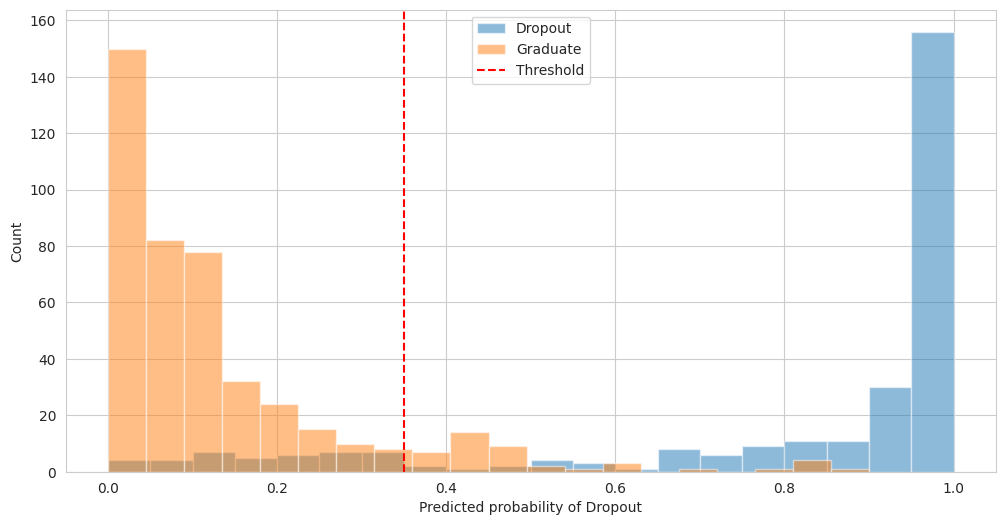

In [34]:
#Base Model Evaluation
print("\n" + "="*60)
print("Baseline Random Forest")
print("="*60)
print("Accuracy: {:.4f}".format((y_pred_base == y_test).mean()))
print("ROC AUC: {:.4f}".format(roc_auc_score(y_test == 0, y_proba_base))) # Fixed TypeError: pos_label=0 was problematic
print("\nClassification Report:")
print(classification_report(y_test, y_pred_base, target_names=['Dropout', 'Graduate']))

#display
plt.hist(y_proba_base[y_test==0], bins=20, alpha=0.5, label='Dropout')
plt.hist(y_proba_base[y_test==1], bins=20, alpha=0.5, label='Graduate')
plt.axvline(threshold, color='red', linestyle='--', label='Threshold')
plt.xlabel('Predicted probability of Dropout') # Label is consistent with y_proba_base being prob of Dropout
plt.ylabel('Count')
plt.legend()
plt.show()

In [35]:
#Hyperparameter Tuning (RandomizedCV)
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', None]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_tuned = RandomForestClassifier(random_state=42, n_jobs=-1)

recall_dropout_scorer = make_scorer(recall_score, pos_label=0)  # recall for class 0 (Dropout)

random_search = RandomizedSearchCV(
    estimator=rf_tuned,
    param_distributions=param_dist,
    n_iter=20,
    cv=cv,
    scoring=recall_dropout_scorer,
    n_jobs=-1,
    random_state=42,
    verbose=1
)
random_search.fit(X_train_balanced, y_train_balanced)
best_rf = random_search.best_estimator_

y_pred_tuned = best_rf.predict(X_test_capped)
y_proba_tuned = best_rf.predict_proba(X_test_capped)

prob_dropout = y_proba_tuned[:, 0]
prob_graduate = y_proba_tuned[:, 1]

print("\nBest parameters:", random_search.best_params_)
print(f"Best Cross-Validation F1 score: {random_search.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None, 'class_weight': None}
Best Cross-Validation F1 score: 0.9004


In [36]:
# Pause execution until user presses Enter
#input("Press Enter to continue to the next phase...")

## Evaluation

In [37]:
print(le.classes_)

['Dropout' 'Graduate']


In [38]:
#Metrics
acc = accuracy_score(y_test, y_pred_tuned)
prec = precision_score(y_test, y_pred_tuned, pos_label=0)
rec = recall_score(y_test, y_pred_tuned, pos_label=0)
f1 = f1_score(y_test, y_pred_tuned, pos_label=0)
auc = roc_auc_score(y_test == 0, prob_dropout)  #calculating AUC for Dropout as positive class

print("="*60)
print("Tuned Random Forest")
print("="*60)
print(f"Accuracy:            {acc:.4f}")
print(f"Precision (Dropout): {prec:.4f}")
print(f"Recall (Dropout):    {rec:.4f}")
print(f"F1 (Dropout):        {f1:.4f}")
print(f"ROC AUC (Dropout):  {auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned, target_names=['Dropout', 'Graduate']))

Tuned Random Forest
Accuracy:            0.9160
Precision (Dropout): 0.9373
Recall (Dropout):    0.8415
F1 (Dropout):        0.8868
ROC AUC (Dropout):  0.9543

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.94      0.84      0.89       284
    Graduate       0.90      0.96      0.93       442

    accuracy                           0.92       726
   macro avg       0.92      0.90      0.91       726
weighted avg       0.92      0.92      0.92       726



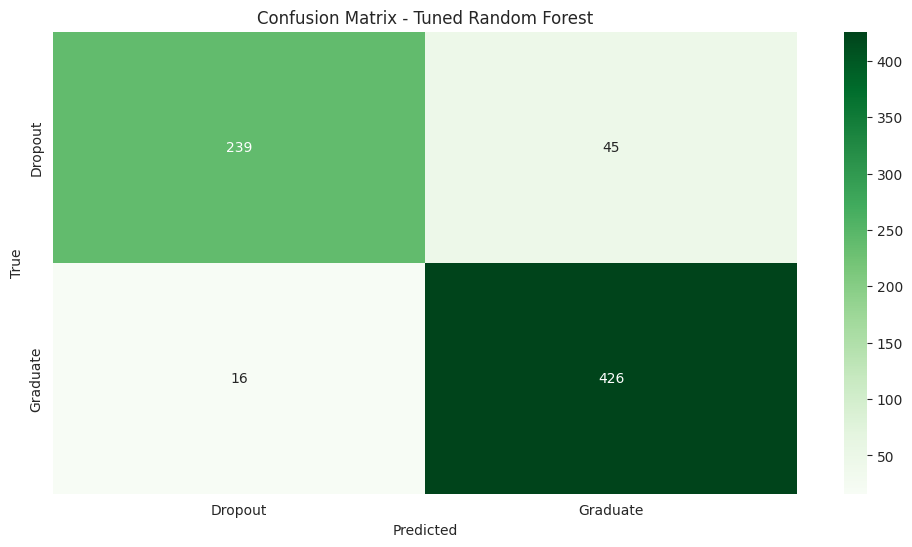

In [39]:
#Confusion Matrixes
cm = confusion_matrix(y_test, y_pred_tuned)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Dropout', 'Graduate'],
            yticklabels=['Dropout', 'Graduate'])
plt.title('Confusion Matrix - Tuned Random Forest')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()

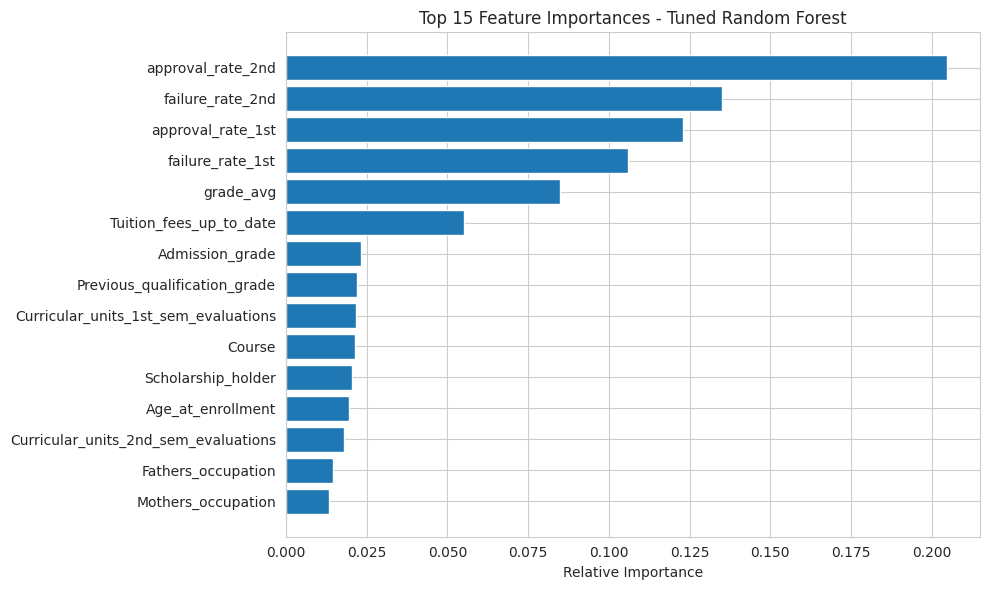

In [40]:
#Feature Importances (Tuned Model)
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1][:15]

plt.figure(figsize=(10, 6))
plt.title('Top 15 Feature Importances - Tuned Random Forest')
plt.barh(range(15), importances[indices][::-1], align='center')
plt.yticks(range(15), [X.columns[i] for i in indices][::-1])
plt.xlabel('Relative Importance')
plt.tight_layout()
plt.show()

#Save Best Model

In [41]:
joblib.dump(best_rf, 'model/best_model.pkl')
joblib.dump(bounds, 'model/bounds.pkl')
joblib.dump(numeric_cols, 'model/numeric_cols.pkl')
joblib.dump(X.columns.tolist(), 'model/feature_names.pkl')
joblib.dump(le, 'model/label_encoder.pkl')
print("\nBest model saved")


Best model saved
